
# Tutorial: POD and SPOD classes
-------------------------------
Demonstrates the ``POD`` and ``SPOD`` classes from ``tools``,
applied to DNS data of the wake past a circular cylinder at Re = 100.


POD / SPOD API
--------

```
  from tools import POD, SPOD

  X_raw = np.array([ux_raw, uy_raw])              # (2, N_t, Nx, Ny)
  pod   = POD(n_modes=20, method='exact').fit(X_raw)
  spod  = SPOD(Nf=Nf, filter_kind='gaussian').fit(X_raw)

  Q         = pod.preprocess_snapshot(X_raw)      # (N_fluid*2, N_t) zero-mean
  N_fluid   = pod.fluid_mask_flat.sum()

  Z     = pod.encode(X_raw)        # (N_modes, N_t) — same as pod.Phi
  Q_hat = pod.decode(Z)            # (N_fluid*2, N_t) with temporal mean added
  mse   = np.mean((Q - pod.Psi @ pod.Phi) ** 2)

  POD.plot_spectrum(pod)
  POD.plot_time_coefficients(pod, num_modes=10)
  mode_2d = to_grid(pod.Psi[:N_fluid, k])
```

Contents
--------
  1. Setup and data loading
  2. Fit POD (exact solver)
  3. Energy spectrum
  4. Spatial modes
  5. Temporal coefficients
  6. Encode / decode / reconstruct
  7. SPOD — Sieber 2016 (same API, one extra parameter)
  8. POD vs SPOD comparison
  9. Towne SPOD (Welch / per-frequency eigenproblem)



In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.io import loadmat

from romda.utils import set_working_directories, get_wake_data

# ── POD / SPOD classes ────────────────────────────────────────────────────────
from romda.models.data_driven.autoencoders import POD, SPOD, spod_towne, print_spod_towne_summary



In [2]:
data_folder = set_working_directories('wakes')[0]
get_wake_data(data_folder)  # Download the data from Zenodo if not already present

mat    = loadmat(os.path.join(data_folder, 'circle_re_100.mat'))
ux_raw = mat['ux']   # (N_t, Nx, Ny) — NaN marks cylinder body interior
uy_raw = mat['uy']
N_t, Nx, Ny = ux_raw.shape
print(f'Snapshots  : N_t = {N_t}')
print(f'Grid       : {Nx} × {Ny}')

# POD.fit() calls preprocess_snapshot() internally, which:
#   • detects the NaN mask (cylinder interior) from the first snapshot
#   • flattens fluid points to (N_fluid*Nu, N_t) and subtracts temporal mean
#   • stores fluid_mask_flat and grid_shape on the instance
#
# Stacking [ux, uy] as axis-0 gives modes that capture both velocity components.
N_modes = 20
X_raw   = np.array([ux_raw, uy_raw])           # (2, N_t, Nx, Ny)
pod     = POD(n_modes=N_modes, method='exact').fit(X_raw)

N_fluid    = int(pod.fluid_mask_flat.sum())
fluid_mask = pod.fluid_mask_flat.reshape(Nx, Ny)

def to_grid(vec):
    """(N_fluid,) --> (Nx, Ny) with NaN at solid-body points."""
    g = np.full(Nx * Ny, np.nan)
    g[pod.fluid_mask_flat] = np.real(vec)
    return g.reshape(Nx, Ny)

Q = pod.preprocess_snapshot(X_raw)             # (N_fluid*2, N_t) zero-mean flat matrix

print(f'\nData matrix Q : {Q.shape}   (2 × {N_fluid} fluid pts, {N_t} snapshots)')
print(f'Cylinder body : {(~fluid_mask).sum()} NaN pts excluded')


File 'circle_re_100.mat' already exists. Skipping download.
File 'README.md' already exists. Skipping download.


Snapshots  : N_t = 800
Grid       : 513 × 129



Data matrix Q : (130644, 800)   (2 × 65322 fluid pts, 800 snapshots)
Cylinder body : 855 NaN pts excluded


/tmp/ipykernel_1742321/4075367569.py:2: RuntimeWarning: Mean of empty slice
  ux_raw[N_t // 2] - np.nanmean(ux_raw, axis=0))


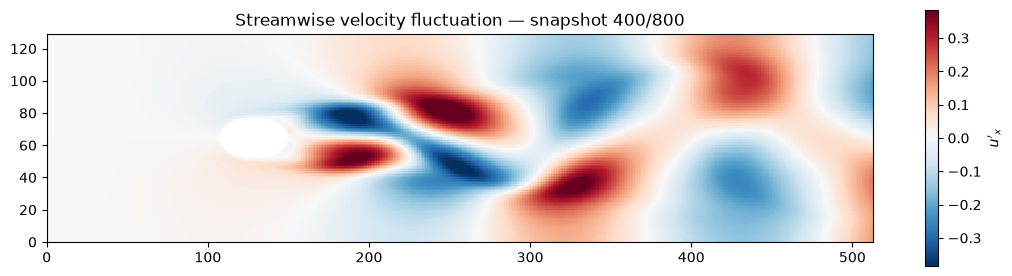

In [3]:
snap = np.where(~fluid_mask, np.nan,
                ux_raw[N_t // 2] - np.nanmean(ux_raw, axis=0))

fig, ax = plt.subplots(figsize=(11, 3.5))
vmax = np.nanpercentile(np.abs(snap), 99)
im   = ax.pcolormesh(snap.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label="$u'_x$")
ax.set_aspect('equal')
ax.set_title(f"Streamwise velocity fluctuation — snapshot {N_t//2}/{N_t}")
plt.tight_layout(); plt.show()




# POD  —  sklearn-style interface

```
  pod = POD(n_modes, method)   # method: 'exact' | 'randomized' (default)
  pod.fit(Q)                   # learn modes from zero-mean Q (N_x, N_t)

After fit():
  pod.Psi    (N_x, N_modes)   spatial modes, orthonormal columns
  pod.Phi    (N_modes, N_t)   temporal coefficients
  pod.Sigma  (N_modes,)       singular values  Σ_k = √λ_k
  pod.Q_mean (N_x, 1)         temporal mean
```

In [4]:

print(f'Fitted POD : {pod.N_modes} modes')
print(f'Psi   : {pod.Psi.shape}')
print(f'Phi   : {pod.Phi.shape}')
print(f'Sigma : {pod.Sigma.shape}')
print(f'Leading singular values: {pod.Sigma[:6].round(4)}')



Fitted POD : 20 modes
Psi   : (130644, 20)
Phi   : (20, 800)
Sigma : (20,)
Leading singular values: [47.3582 46.2004  8.624   8.5254  6.055   6.017 ]


Mode 1     : 48.71% energy
Modes 1-2  : 95.08%
Modes 1-4  : 98.27%


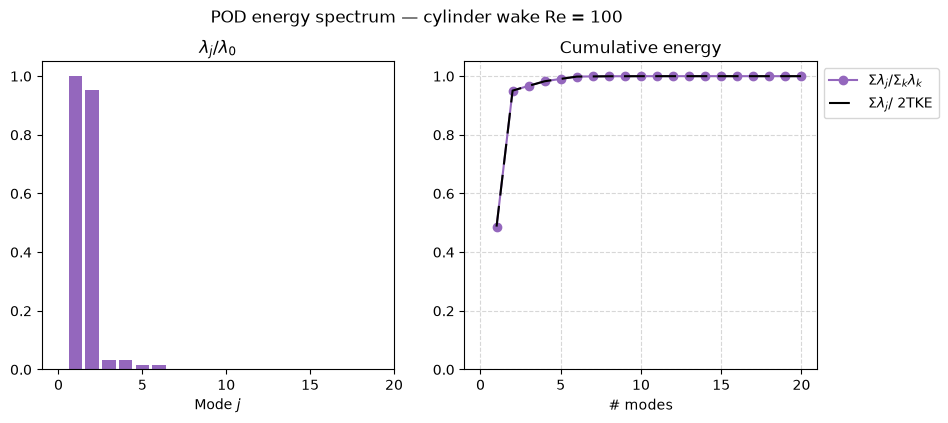

In [5]:
from romda.plotting.pod import plot_spectrum, plot_time_coefficients

rel, cum = pod.energy_fraction()
print(f'Mode 1     : {rel[0]*100:.2f}% energy')
print(f'Modes 1-2  : {cum[1]*100:.2f}%')
print(f'Modes 1-4  : {cum[3]*100:.2f}%')

plot_spectrum(pod, max_mode=N_modes)
plt.suptitle('POD energy spectrum — cylinder wake Re = 100', fontsize=12, y=1.01)
plt.show()

# Modes 1 & 2 form a conjugate pair (equal energy) = Kármán vortex shedding.
# Modes 3 & 4 capture the first harmonic.



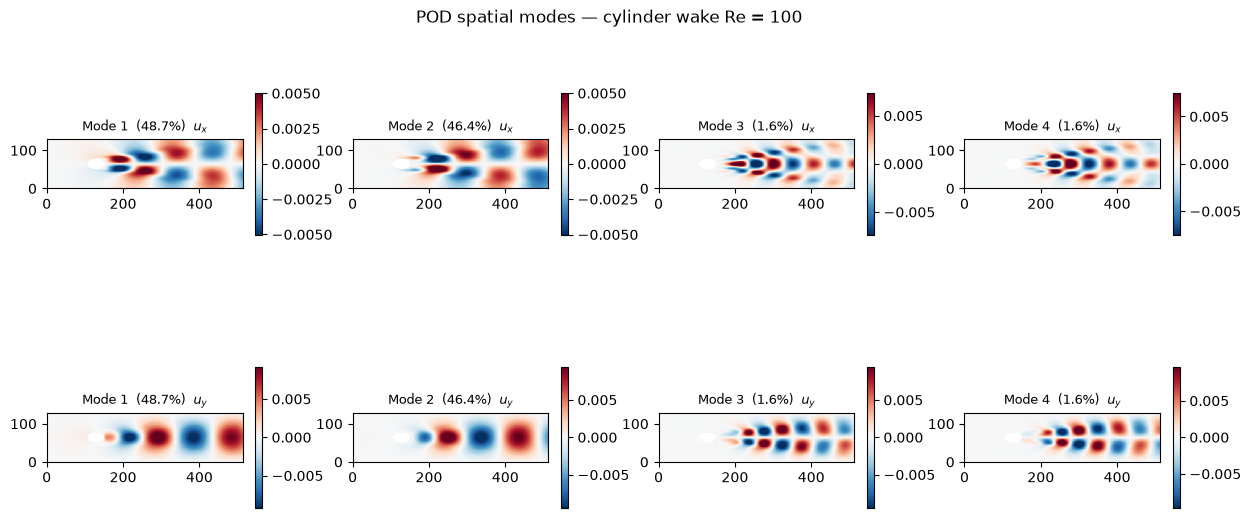

In [6]:
# Psi rows: first N_fluid = ux component, next N_fluid = uy component
Psi_ux = pod.Psi[:N_fluid, :]    # (N_fluid, N_modes)
Psi_uy = pod.Psi[N_fluid:, :]

n_show = 4
fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(2, n_show, hspace=0.45, wspace=0.25)

for k in range(n_show):
    for row, Psi_c, label in [(0, Psi_ux, '$u_x$'), (1, Psi_uy, '$u_y$')]:
        mode_2d = to_grid(Psi_c[:, k])
        vmax    = np.nanpercentile(np.abs(mode_2d), 98)
        ax      = fig.add_subplot(gs[row, k])
        im      = ax.pcolormesh(mode_2d.T, cmap='RdBu_r',
                                vmin=-vmax, vmax=vmax, shading='auto')
        plt.colorbar(im, ax=ax, shrink=0.75)
        ax.set_title(f'Mode {k+1}  ({rel[k]*100:.1f}%)  {label}', fontsize=9)
        ax.set_aspect('equal')

fig.suptitle('POD spatial modes — cylinder wake Re = 100', fontsize=12)
plt.show()



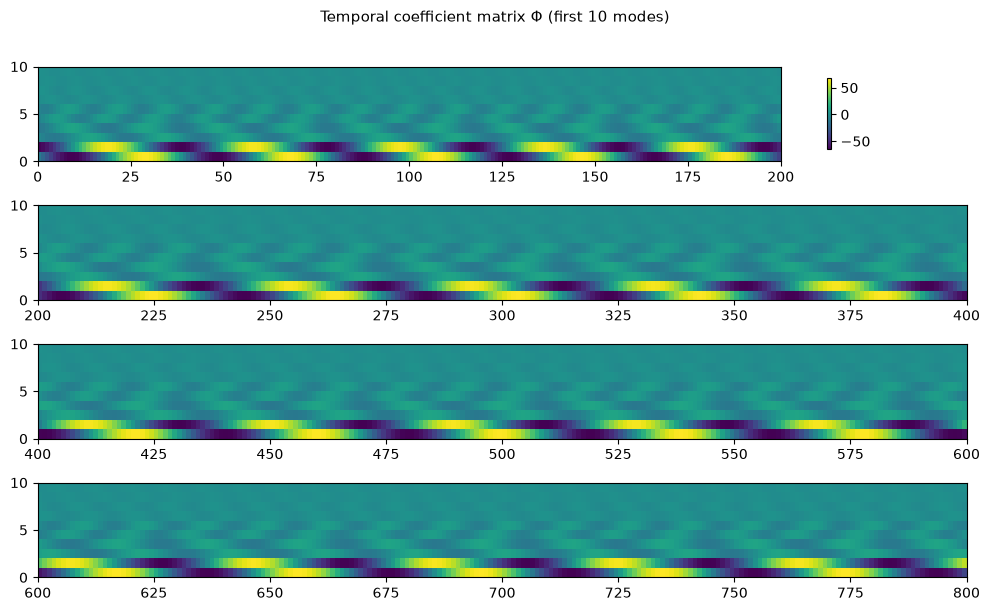

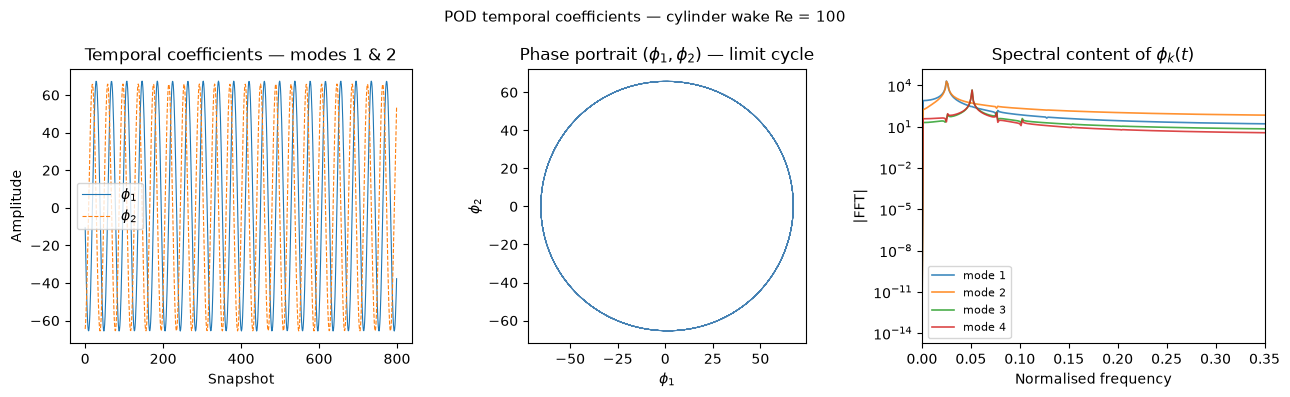

In [7]:
from romda.plotting.pod import plot_spectrum, plot_time_coefficients

plot_time_coefficients(pod, num_modes=10)
plt.suptitle('Temporal coefficient matrix Φ (first 10 modes)', fontsize=11, y=1.01)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(pod.Phi[0], lw=0.8, label='$\\phi_1$')
axes[0].plot(pod.Phi[1], lw=0.8, ls='--', label='$\\phi_2$')
axes[0].set(xlabel='Snapshot', ylabel='Amplitude',
            title='Temporal coefficients — modes 1 & 2')
axes[0].legend()

axes[1].plot(pod.Phi[0], pod.Phi[1], lw=0.5, color='steelblue')
axes[1].set(xlabel='$\\phi_1$', ylabel='$\\phi_2$',
            title='Phase portrait $(\\phi_1, \\phi_2)$ — limit cycle',
            aspect='equal')

freqs = np.fft.rfftfreq(N_t)
for k in range(4):
    axes[2].semilogy(freqs, np.abs(np.fft.rfft(pod.Phi[k])),
                     lw=1.2, alpha=0.85, label=f'mode {k+1}')
axes[2].set_xlim(0, 0.35)
axes[2].set(xlabel='Normalised frequency', ylabel='|FFT|',
            title='Spectral content of $\\phi_k(t)$')
axes[2].legend(fontsize=8)

plt.suptitle('POD temporal coefficients — cylinder wake Re = 100', fontsize=11)
plt.tight_layout(); plt.show()



```
  Z     = pod.encode(Q)             (N_modes, N_t)   latent representation
  Q_hat = pod.decode(Z)             (N_x, N_t)       state-space reconstruction
  Q_hat = pod.reconstruct(Q)        round-trip  encode → decode
  Q_hat = pod.reconstruct(Q, n_modes=r)  truncated reconstruction with r modes
  mse   = pod.score(Q)              mean squared reconstruction error

  ```

Latent Z    : (20, 800)
Q_hat       : (130644, 800)
encode(X_raw) == Phi: True


MSE (20 modes): 3.02e-09


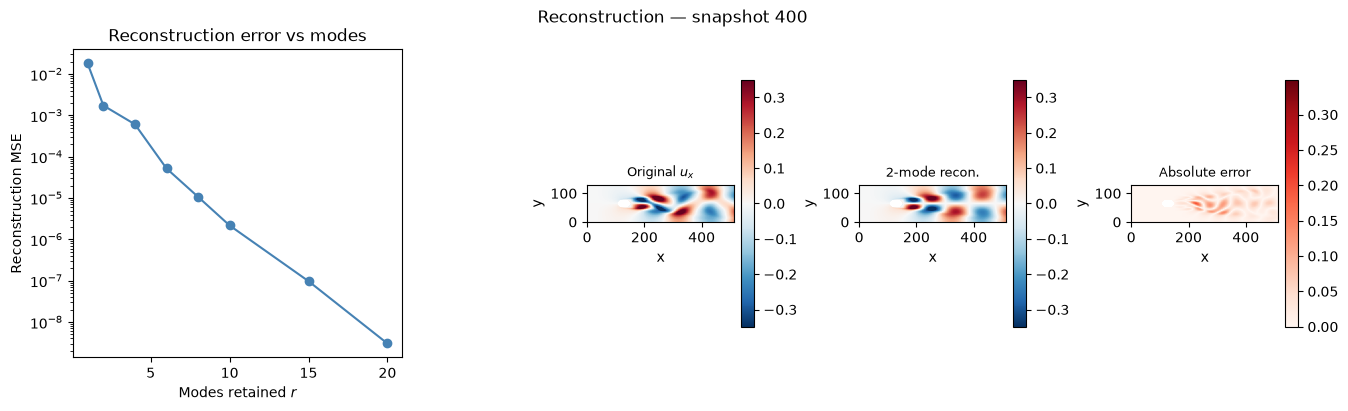

In [8]:

#
Z     = pod.encode(X_raw)
Q_hat = pod.decode(Z)

print(f'Latent Z    : {Z.shape}')
print(f'Q_hat       : {Q_hat.shape}')
print(f'encode(X_raw) == Phi: {np.allclose(Z, pod.Phi, atol=1e-10)}')
mse_full = float(np.mean((Q - pod.Psi @ pod.Phi) ** 2))
print(f'MSE ({N_modes} modes): {mse_full:.2e}')

# Reconstruction error vs number of modes retained
mode_range = [1, 2, 4, 6, 8, 10, 15, 20]
mse_list   = [float(np.mean((Q - pod.Psi[:, :r] @ (pod.Psi[:, :r].T @ Q)) ** 2))
              for r in mode_range]

snap_idx = N_t // 2
Q_r2     = pod.Psi[:, :2] @ (pod.Psi[:, :2].T @ Q)  # 2-mode zero-mean reconstruction
vmax     = np.nanpercentile(np.abs(to_grid(Q[:N_fluid, snap_idx])), 98)

fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2.2], wspace=0.35)

# left: MSE vs modes
ax_mse = fig.add_subplot(gs[0])
ax_mse.semilogy(mode_range, mse_list, 'o-', color='steelblue')
ax_mse.set(xlabel='Modes retained $r$', ylabel='Reconstruction MSE',
           title='Reconstruction error vs modes')

# right: three flow-field panels
gs_right = gs[1].subgridspec(1, 3, wspace=0.5)
for col, (data, title, cmap) in enumerate([
        (to_grid(Q[:N_fluid, snap_idx]),                                    'Original $u_x$', 'RdBu_r'),
        (to_grid(Q_r2[:N_fluid, snap_idx]),                                 '2-mode recon.',  'RdBu_r'),
        (to_grid(np.abs(Q[:N_fluid, snap_idx] - Q_r2[:N_fluid, snap_idx])), 'Absolute error', 'Reds'),
    ]):
    ax = fig.add_subplot(gs_right[col])
    kw = dict(vmin=-vmax, vmax=vmax) if cmap == 'RdBu_r' else dict(vmin=0, vmax=vmax)
    im = ax.pcolormesh(data.T, cmap=cmap, shading='auto', **kw)
    plt.colorbar(im, ax=ax, shrink=0.8, pad=0.04)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle(f'Reconstruction — snapshot {snap_idx}', fontsize=12)
plt.show()



## SPOD has the same interface as POD — only `Nf` (filter half-width) is added.

  spod = SPOD(Nf=Nf, filter_kind='gaussian').fit(Q)

Internally, the correlation matrix C is replaced by:

  C_tilde = G^T C G

where G is a banded symmetric Toeplitz filter matrix.
Setting Nf=0 recovers standard snapshot POD exactly.
Setting Nf → N_t/2 recovers the DFT.

A natural choice for Nf is half the dominant temporal scale (here, the
Kármán shedding period).

In [9]:
#
fft_phi1 = np.abs(np.fft.rfft(pod.Phi[0]))
f_peak   = np.fft.rfftfreq(N_t)[np.argmax(fft_phi1)]
T_snaps  = int(round(1.0 / f_peak))
Nf       = T_snaps // 2

print(f'Dominant frequency : f = {f_peak:.4f}  (normalised)')
print(f'Shedding period    : ~{T_snaps} snapshots')
print(f'Filter half-width  : Nf = {Nf}')

spod = SPOD(Nf=Nf, filter_kind='gaussian', n_modes=N_modes).fit(X_raw)
print(f'\nSPOD fitted: {spod.N_modes} modes')

# SPOD reconstruction API is identical to POD
Q_spod   = spod.preprocess_snapshot(X_raw)
mse_spod = float(np.mean((Q_spod - spod.Psi @ (spod.Psi.T @ Q_spod)) ** 2))
print(f'SPOD MSE ({N_modes} modes): {mse_spod:.2e}')



Dominant frequency : f = 0.0250  (normalised)
Shedding period    : ~40 snapshots
Filter half-width  : Nf = 20



SPOD fitted: 20 modes


SPOD MSE (20 modes): 5.32e+11


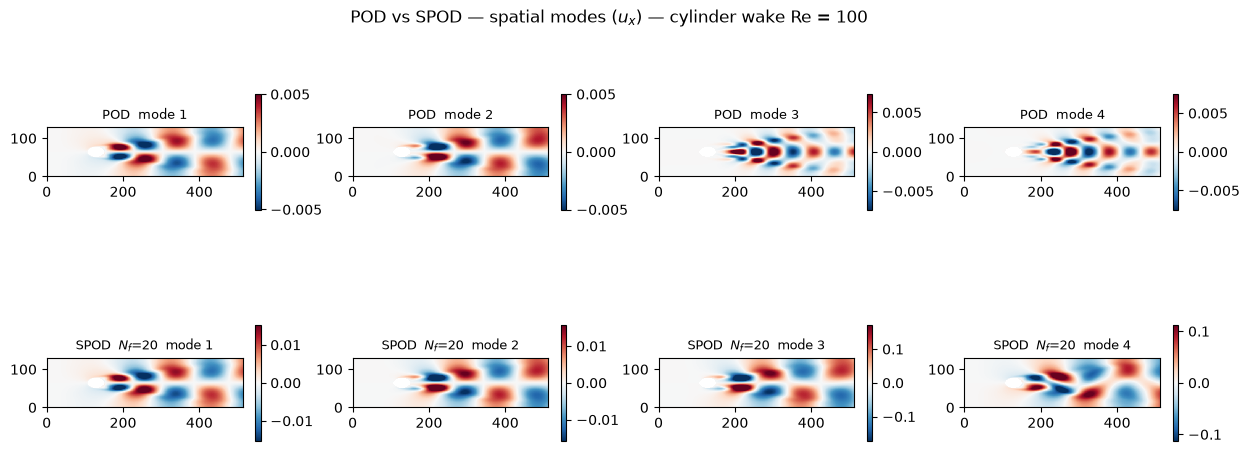

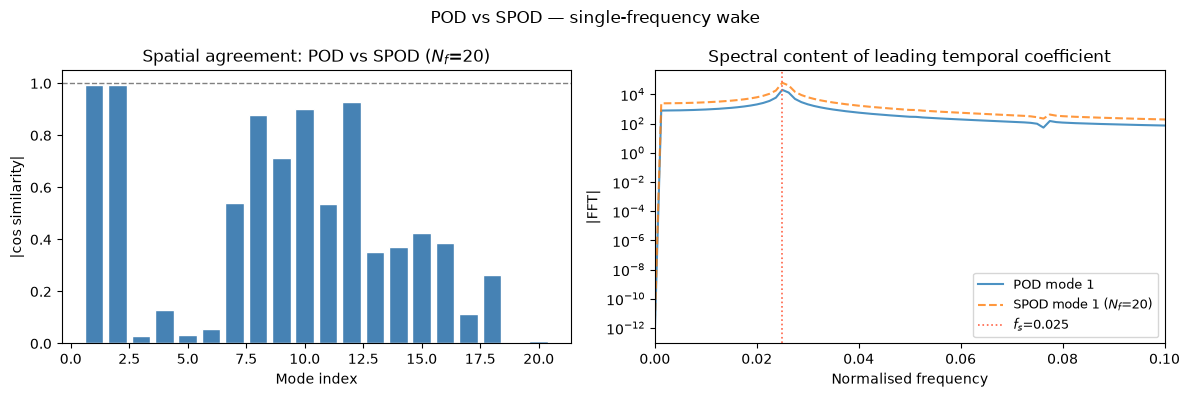


For this single-frequency flow, SPOD reproduces POD modes with near-unity similarity.
SPOD adds the most value for multi-frequency flows (harmonics, competing instabilities).


In [10]:
n_comp = 4
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(2, n_comp, hspace=0.50, wspace=0.25)

for k in range(n_comp):
    for row, psi_src, label in [
            (0, pod.Psi[:N_fluid, :],  'POD'),
            (1, spod.Psi[:N_fluid, :], f'SPOD  $N_f$={Nf}'),
        ]:
        mode_2d = to_grid(psi_src[:, k])
        vmax    = np.nanpercentile(np.abs(mode_2d), 98)
        ax      = fig.add_subplot(gs[row, k])
        im      = ax.pcolormesh(mode_2d.T, cmap='RdBu_r',
                                vmin=-vmax, vmax=vmax, shading='auto')
        plt.colorbar(im, ax=ax, shrink=0.75)
        ax.set_title(f'{label}  mode {k+1}', fontsize=9)
        ax.set_aspect('equal')

fig.suptitle('POD vs SPOD — spatial modes ($u_x$) — cylinder wake Re = 100',
             fontsize=12, y=1.01)
plt.show()

# Quantitative: cosine similarity between POD and SPOD modes
cos_sim = np.array([
    abs(pod.Psi[:, k] @ spod.Psi[:, k]) /
    (np.linalg.norm(pod.Psi[:, k]) * np.linalg.norm(spod.Psi[:, k]))
    for k in range(N_modes)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, N_modes + 1), cos_sim, color='steelblue', edgecolor='white')
axes[0].axhline(1.0, lw=1, ls='--', color='gray')
axes[0].set(ylim=[0, 1.05], xlabel='Mode index', ylabel='|cos similarity|',
            title=f'Spatial agreement: POD vs SPOD ($N_f$={Nf})')

axes[1].semilogy(freqs, np.abs(np.fft.rfft(pod.Phi[0])),
                 lw=1.5, alpha=0.8, label='POD mode 1')
axes[1].semilogy(freqs, np.abs(np.fft.rfft(spod.Phi[0])),
                 lw=1.5, alpha=0.8, ls='--', label=f'SPOD mode 1 ($N_f$={Nf})')
axes[1].axvline(f_peak, color='tomato', lw=1.2, ls=':', label=f'$f_s$={f_peak:.3f}')
axes[1].set_xlim(0, 4 * f_peak)
axes[1].set(xlabel='Normalised frequency', ylabel='|FFT|',
            title='Spectral content of leading temporal coefficient')
axes[1].legend(fontsize=9)

plt.suptitle('POD vs SPOD — single-frequency wake', fontsize=12)
plt.tight_layout(); plt.show()

print('\nFor this single-frequency flow, SPOD reproduces POD modes with near-unity similarity.')
print('SPOD adds the most value for multi-frequency flows (harmonics, competing instabilities).')



## Further reading: Towne, Schmidt & Colonius, JFM 2018, 
"Spectral proper orthogonal decomposition and its relationship to dynamic mode decomposition and resolvent analysis"

spod_towne() performs a Welch block-average of the CSD matrix and solves
a per-frequency eigenvalue problem (Towne, Schmidt & Colonius, JFM 2018).
It is a standalone function — no class wrapper yet.

  L, Psi_f, f, Lc, info = spod_towne(Q, dt=1.0)

  L     (n_freq, n_blks)         modal energy spectrum
  Psi_f (n_freq, N_x, n_blks)   complex SPOD spatial modes
  f     (n_freq,)                frequency vector
  Lc    (n_freq, n_blks, 2)      confidence intervals (lower, upper)
  info  dict                     n_fft, n_ovlp, n_blks, n_freq

SPOD (Towne / Welch) parameters
────────────────────────────────
  Snapshots per block (n_fft)  : 64
  Block overlap (n_ovlp)       : 32
  Number of blocks             : 24
  Resolved frequencies         : 33


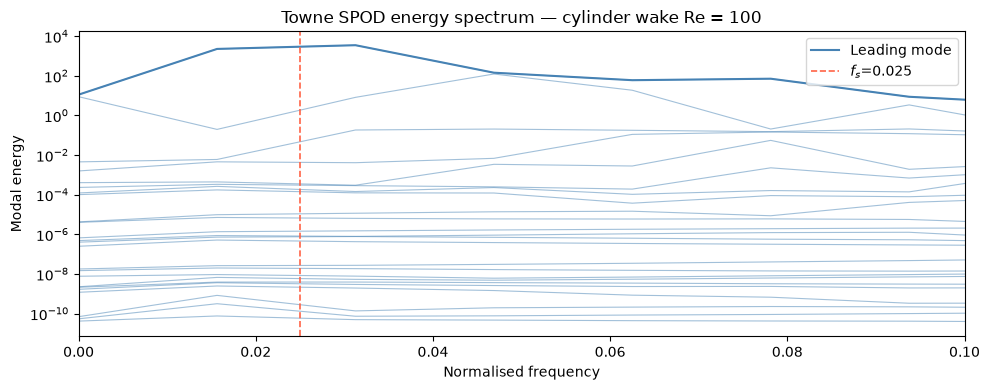

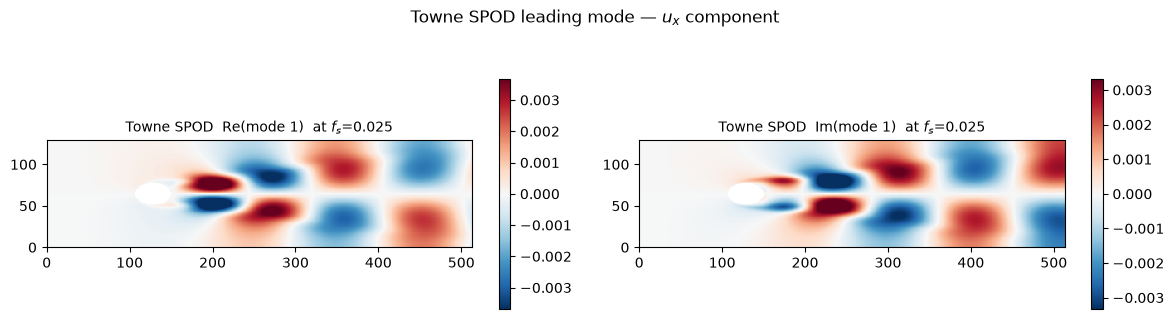

In [11]:


L, Psi_f, f_towne, Lc, info = spod_towne(Q, dt=1.0)
print_spod_towne_summary(info)

fig, ax = plt.subplots(figsize=(10, 4))
for m in range(info['n_blks']):
    ax.semilogy(f_towne, L[:, m], color='steelblue', lw=0.8, alpha=0.5)
ax.semilogy(f_towne, L[:, 0], color='steelblue', lw=1.5, label='Leading mode')
ax.axvline(f_peak, color='tomato', ls='--', lw=1.2, label=f'$f_s$={f_peak:.3f}')
ax.set(xlabel='Normalised frequency', ylabel='Modal energy',
       title='Towne SPOD energy spectrum — cylinder wake Re = 100',
       xlim=[0, 4 * f_peak])
ax.legend(); plt.tight_layout(); plt.show()

# Leading spatial mode at the shedding frequency
idx_fs       = np.argmin(np.abs(f_towne - f_peak))
leading_mode = Psi_f[idx_fs, :N_fluid, 0]   # complex mode, ux component

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, data, title in [
        (axes[0], to_grid(leading_mode.real), 'Re(mode 1)'),
        (axes[1], to_grid(leading_mode.imag), 'Im(mode 1)'),
    ]:
    vmax = np.nanpercentile(np.abs(data[~np.isnan(data)]), 98)
    im   = ax.pcolormesh(data.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'Towne SPOD  {title}  at $f_s$={f_peak:.3f}', fontsize=10)
    ax.set_aspect('equal')

plt.suptitle('Towne SPOD leading mode — $u_x$ component', fontsize=12)
plt.tight_layout(); plt.show()

